# PCam baseline training

Run cells in order. If training fails, you can re-run from **3. Build model** or **4. Train** without re-loading data.

## 1. Setup and load data (run once)

In [2]:
import os
import sys
import json
import numpy as np

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'pcam-master'))

DATA_DIR = os.path.join(PROJECT_ROOT, 'pcam_data')
if not os.path.isdir(DATA_DIR):
    DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), 'pcam_data'))

EXPERIMENT_DIR = os.path.join(PROJECT_ROOT, 'experiments', 'pcam_baseline')
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Experiment dir:", EXPERIMENT_DIR)

Project root: c:\GP_ECG
Data dir: c:\GP_ECG\pcam_data
Experiment dir: c:\GP_ECG\experiments\pcam_baseline


In [3]:
from keras_pcam.dataset.pcam import load_data

(train_x, train_y, meta_train), (val_x, val_y, meta_val), (test_x, test_y, meta_test) = load_data(data_dir=DATA_DIR)

n_train = len(train_x)
n_val = len(val_x)
n_test = len(test_x)
print("Train:", n_train, "Val:", n_val, "Test:", n_test)

Train: 262144 Val: 32768 Test: 32768


## 2. Preprocessing and batch generator (run once; re-run only if you change preprocessing)

In [3]:
BATCH_SIZE = 64
IMG_SIZE = 96


def batch_generator(x_data, y_data, batch_size, shuffle=True):
    """Yield batches (x, y) with x normalized to [0, 1]."""
    n = len(x_data)
    indices = np.arange(n)
    if shuffle:
        np.random.shuffle(indices)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = indices[start:end]
        x_batch = np.array([np.asarray(x_data[i]) for i in batch_idx], dtype=np.float32) / 255.0
        y_batch = np.array([np.asarray(y_data[i]).flatten()[0] for i in batch_idx], dtype=np.float32)
        yield x_batch, y_batch


def infinite_train_generator(x_data, y_data, batch_size):
    """Infinite generator for model.fit; reshuffles each full pass."""
    while True:
        for xb, yb in batch_generator(x_data, y_data, batch_size, shuffle=True):
            yield xb, yb


def infinite_val_generator(x_data, y_data, batch_size):
    """Infinite validation generator (repeats so fit() can run multiple epochs)."""
    while True:
        for xb, yb in batch_generator(x_data, y_data, batch_size, shuffle=False):
            yield xb, yb


def steps_per_epoch(n_samples, batch_size):
    return max(1, n_samples // batch_size)


train_steps = steps_per_epoch(n_train, BATCH_SIZE)
val_steps = steps_per_epoch(n_val, BATCH_SIZE)
print("Train steps per epoch:", train_steps, "| Val steps:", val_steps)

Train steps per epoch: 4096 | Val steps: 512


In [4]:
# Optional: quick sanity check — one batch from train
for xb, yb in batch_generator(train_x, train_y, BATCH_SIZE, shuffle=True):
    print("Batch shape:", xb.shape, yb.shape, "| x range:", xb.min(), "-", xb.max())
    break

Batch shape: (64, 96, 96, 3) (64,) | x range: 0.0 - 1.0


## 3. Build model (re-run to reset model without re-loading data)

In [4]:
try:
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError:
    import keras
    from keras import layers


def build_baseline_cnn(input_shape=(96, 96, 3)):
    """Small CNN for 96x96 RGB patches, binary classification."""
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPool2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D(2)(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    return model


model = build_baseline_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train (re-run to retry training; data already in memory)

In [7]:
# Custom callback: print clear per-epoch summary + early batch updates in epoch 0
class PrintProgress(keras.callbacks.Callback):
    def __init__(self, steps_per_epoch, log_every_n_batches=500):
        super().__init__()
        self.steps_per_epoch = steps_per_epoch
        self.log_every = log_every_n_batches

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get("loss", "?")
        acc = logs.get("accuracy", "?")
        v_loss = logs.get("val_loss", "?")
        v_acc = logs.get("val_accuracy", "?")
        if isinstance(acc, (int, float)):
            acc = f"{acc:.4f}"
        if isinstance(v_acc, (int, float)):
            v_acc = f"{v_acc:.4f}"
        if isinstance(loss, (int, float)):
            loss = f"{loss:.4f}"
        if isinstance(v_loss, (int, float)):
            v_loss = f"{v_loss:.4f}"
        print(f"\n  Epoch {epoch + 1}/{self.params.get('epochs', '?')} — loss: {loss}, acc: {acc} | val_loss: {v_loss}, val_acc: {v_acc}")

    def on_batch_end(self, batch, logs=None):
        if self.model.stop_training:
            return
        epoch = getattr(self, "_current_epoch", 0)
        if epoch > 0:
            return
        if (batch + 1) % self.log_every == 0 or batch == 0:
            logs = logs or {}
            l = logs.get("loss", "?")
            a = logs.get("accuracy", "?")
            if isinstance(l, (int, float)):
                l = f"{l:.4f}"
            if isinstance(a, (int, float)):
                a = f"{a:.4f}"
            print(f"  Epoch 1 — step {batch + 1}/{self.steps_per_epoch} — loss: {l}, acc: {a}")

    def on_epoch_begin(self, epoch, logs=None):
        self._current_epoch = epoch


# Callback: print validation confusion matrix each epoch (catches class imbalance / all-one-class)
class ConfusionMatrixCallback(keras.callbacks.Callback):
    def __init__(self, val_x, val_y, pred_batch_size=256):
        super().__init__()
        self.val_x = val_x
        self.val_y = val_y
        self.pred_batch_size = pred_batch_size

    def on_epoch_end(self, epoch, logs=None):
        from sklearn.metrics import confusion_matrix
        n = len(self.val_y)
        y_true = np.array([np.asarray(self.val_y[i]).flatten()[0] for i in range(n)], dtype=np.float32)
        y_pred_proba = []
        for start in range(0, n, self.pred_batch_size):
            end = min(start + self.pred_batch_size, n)
            x_batch = np.array([np.asarray(self.val_x[i]) for i in range(start, end)], dtype=np.float32) / 255.0
            p = self.model.predict(x_batch, verbose=0)
            y_pred_proba.append(p.flatten())
        y_pred = (np.concatenate(y_pred_proba) >= 0.5).astype(np.float32)
        cm = confusion_matrix(y_true, y_pred)
        print(f"  Val confusion matrix (true \u2192 rows, pred \u2192 cols):")
        print(f"              pred_0  pred_1")
        print(f"    true_0    {cm[0,0]:6d}  {cm[0,1]:6d}")
        print(f"    true_1    {cm[1,0]:6d}  {cm[1,1]:6d}")


EPOCHS = 10  # increase as needed

train_gen = infinite_train_generator(train_x, train_y, BATCH_SIZE)
val_gen = infinite_val_generator(val_x, val_y, BATCH_SIZE)

callbacks = [
    PrintProgress(train_steps, log_every_n_batches=500),
    ConfusionMatrixCallback(val_x, val_y, pred_batch_size=256),
    keras.callbacks.ModelCheckpoint(
        os.path.join(EXPERIMENT_DIR, "model_best.weights.h5"),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(os.path.join(EXPERIMENT_DIR, "training_log.csv")),
]

print("Training started. Early updates every 500 steps in epoch 1; full summary at end of each epoch.\n")
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1,
)

Training started. Early updates every 500 steps in epoch 1; full summary at end of each epoch.



Epoch 1/10
  Epoch 1 — step 1/4096 — loss: 0.6990, acc: 0.4375
 499/4096 ━━━━━━━━━━━━━━━━━━━━ 1:42:34 2s/step - accuracy: 0.7027 - loss: 0.5532  Epoch 1 — step 500/4096 — loss: 0.5052, acc: 0.7554
 999/4096 ━━━━━━━━━━━━━━━━━━━━ 1:28:09 2s/step - accuracy: 0.7353 - loss: 0.5213  Epoch 1 — step 1000/4096 — loss: 0.4780, acc: 0.7765
1499/4096 ━━━━━━━━━━━━━━━━━━━━ 1:13:48 2s/step - accuracy: 0.7517 - loss: 0.5031  Epoch 1 — step 1500/4096 — loss: 0.4557, acc: 0.7918
1999/4096 ━━━━━━━━━━━━━━━━━━━━ 59:32 2s/step - accuracy: 0.7632 - loss: 0.4888  Epoch 1 — step 2000/4096 — loss: 0.4351, acc: 0.8038
2499/4096 ━━━━━━━━━━━━━━━━━━━━ 45:18 2s/step - accuracy: 0.7724 - loss: 0.4763  Epoch 1 — step 2500/4096 — loss: 0.4176, acc: 0.8136
2999/4096 ━━━━━━━━━━━━━━━━━━━━ 31:06 2s/step - accuracy: 0.7799 - loss: 0.4653  Epoch 1 — step 3000/4096 — loss: 0.4038, acc: 0.8217
3499/4096 ━━━━━━━━━━━━━━━━━━━━ 16:55 2s/step - accuracy: 0.7865 - loss: 0.4554  Epoch 1 — step 3500/4096 — loss: 0.3895, acc: 0.8295
3

## 5. Evaluate on validation and test

In [5]:
# Load best weights for evaluation
best_path = os.path.join(EXPERIMENT_DIR, "model_best.weights.h5")
if os.path.exists(best_path):
    model.load_weights(best_path)
    print("Loaded best weights from", best_path)
else:
    print("No saved weights; using last epoch.")

Loaded best weights from c:\GP_ECG\experiments\pcam_baseline\model_best.weights.h5


c:\GP_ECG\.venv\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [9]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix


def evaluate_split(model, x_data, y_data, batch_size=256, name=""):
    """Compute loss, accuracy, AUC; optionally confusion matrix."""
    y_true = np.array([np.asarray(y_data[i]).flatten()[0] for i in range(len(y_data))], dtype=np.float32)
    y_pred_proba = []
    for start in range(0, len(y_true), batch_size):
        end = min(start + batch_size, len(y_true))
        x_batch = np.array([np.asarray(x_data[i]) for i in range(start, end)], dtype=np.float32) / 255.0
        p = model.predict(x_batch, verbose=0)
        y_pred_proba.append(p.flatten())
    y_pred_proba = np.concatenate(y_pred_proba)
    y_pred = (y_pred_proba >= 0.5).astype(np.float32)

    auc = roc_auc_score(y_true, y_pred_proba)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return {"auc": float(auc), "accuracy": float(acc), "confusion_matrix": cm.tolist(), "n": len(y_true)}, y_pred_proba


val_metrics, _ = evaluate_split(model, val_x, val_y, name="val")
test_metrics, _ = evaluate_split(model, test_x, test_y, name="test")

print("Validation — AUC:", round(val_metrics["auc"], 4), "| Accuracy:", round(val_metrics["accuracy"], 4))
print("Test       — AUC:", round(test_metrics["auc"], 4), "| Accuracy:", round(test_metrics["accuracy"], 4))
print("Val confusion matrix:", val_metrics["confusion_matrix"])
print("Test confusion matrix:", test_metrics["confusion_matrix"])

Validation — AUC: 0.9341 | Accuracy: 0.8611
Test       — AUC: 0.8768 | Accuracy: 0.8017
Val confusion matrix: [[15173, 1226], [3325, 13044]]
Test confusion matrix: [[15224, 1167], [5332, 11045]]


In [10]:
# Save metrics for the paper / later comparison
results = {
    "val_auc": val_metrics["auc"],
    "val_accuracy": val_metrics["accuracy"],
    "test_auc": test_metrics["auc"],
    "test_accuracy": test_metrics["accuracy"],
    "val_confusion_matrix": val_metrics["confusion_matrix"],
    "test_confusion_matrix": test_metrics["confusion_matrix"],
    "n_train": n_train,
    "n_val": n_val,
    "n_test": n_test,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
}

metrics_path = os.path.join(EXPERIMENT_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(results, f, indent=2)
print("Saved metrics to", metrics_path)

Saved metrics to c:\GP_ECG\experiments\pcam_baseline\metrics.json


Saved figure to c:\GP_ECG\experiments\pcam_baseline\confusion_matrices.png


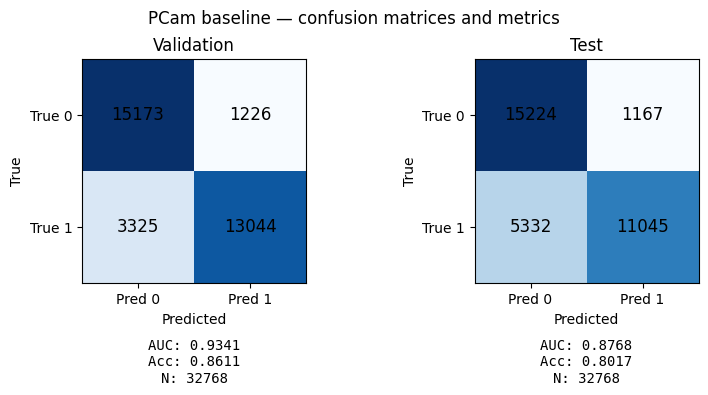

In [7]:
# Confusion matrices figure: load val & test from saved metrics (no recomputation)
import json
import numpy as np
import matplotlib.pyplot as plt

metrics_path = os.path.join(EXPERIMENT_DIR, "metrics.json")
with open(metrics_path) as f:
    m = json.load(f)

val_metrics = {"auc": m["val_auc"], "accuracy": m["val_accuracy"], "confusion_matrix": m["val_confusion_matrix"], "n": m["n_val"]}
test_metrics = {"auc": m["test_auc"], "accuracy": m["test_accuracy"], "confusion_matrix": m["test_confusion_matrix"], "n": m["n_test"]}

splits = [("Validation", val_metrics), ("Test", test_metrics)]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (name, m) in zip(axes, splits):
    cm = np.array(m["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12)
    metrics_text = f"AUC: {m['auc']:.4f}\nAcc: {m['accuracy']:.4f}\nN: {m['n']}"
    ax.text(0.5, -0.25, metrics_text, transform=ax.transAxes, ha="center", va="top", fontsize=10, family="monospace")
plt.suptitle("PCam baseline — confusion matrices and metrics", fontsize=12)
plt.tight_layout()
fig_path = os.path.join(EXPERIMENT_DIR, "confusion_matrices.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved figure to", fig_path)
plt.show()

In [9]:
from huggingface_hub import login
login()